# The Invariant EKF vs. the Error-State KF on $SE(3)$

**Problem:** estimate the pose $\mathbf{T} \in SE(3)$ of a rigid body from noisy body-frame
twist odometry and body-frame observations of known landmarks.

Any Kalman filter on a Lie group has to answer one deceptively simple question: *what is the
estimation error?* On a vector space there is only one sensible answer
($\tilde{\mathbf{x}} = \mathbf{x} - \hat{\mathbf{x}}$), but on $SE(3)$ there are several, and the
choice changes the filter's Jacobians, its consistency, and its convergence basin. This notebook
builds three filters that differ *only* in their error definition, derives their equations, and
races them:

| Filter | Error state | Lives on |
|---|---|---|
| **ESKF** | $\delta\mathbf{p} = \mathbf{p}-\hat{\mathbf{p}}$, &nbsp; $\delta\boldsymbol{\theta} = \mathrm{Log}(\hat{\mathbf{R}}^\top\mathbf{R})$ | $\mathbb{R}^3 \times \mathfrak{so}(3)$ |
| **Left-IEKF** | $\boldsymbol{\xi} = \mathrm{Log}(\hat{\mathbf{T}}^{-1}\mathbf{T})$ (body frame) | $\mathfrak{se}(3)$ |
| **Right-IEKF** | $\boldsymbol{\zeta} = \mathrm{Log}(\mathbf{T}\hat{\mathbf{T}}^{-1})$ (world frame) | $\mathfrak{se}(3)$ |

The ESKF is the classic error-state / multiplicative EKF used in most VIO and GNSS-INS stacks
(Solà's quaternion-ESKF formulation, adapted to rotation-matrix notation). The invariant EKF
(Barrau & Bonnabel) instead defines the error through the group operation of $SE(3)$ itself, and
for the right class of systems this buys two remarkable properties we will derive and then verify
numerically:

1. **Log-linear error propagation** — the error dynamics linearize *exactly*, with a state-estimate-independent transition matrix, no matter how large the error is.
2. **State-independent measurement Jacobians** — for measurements that respect the group symmetry, $H$ depends only on known quantities, so a bad estimate cannot corrupt the gain.

**Audience assumptions:** you know how a Kalman filter works and what $\mathrm{Exp}$/$\mathrm{Log}$,
tangent spaces, and adjoints are. For background, see Solà, Deray & Atchuthan,
[*A micro Lie theory for state estimation in robotics*](https://arxiv.org/abs/1812.01537) (2018).

**References:**
- A. Barrau, S. Bonnabel, [*The invariant extended Kalman filter as a stable observer*](https://arxiv.org/abs/1410.1465), IEEE TAC, 2017.
- A. Barrau, S. Bonnabel, *Invariant Kalman filtering*, Annual Review of Control, Robotics, and Autonomous Systems, 2018.
- R. Hartley, M. Ghaffari, R. M. Eustice, J. W. Grizzle, [*Contact-aided invariant extended Kalman filtering for robot state estimation*](https://arxiv.org/abs/1904.09251), IJRR, 2020.
- J. Solà, [*Quaternion kinematics for the error-state Kalman filter*](https://arxiv.org/abs/1711.02508), 2017.

## 1. Preliminaries and conventions

A pose $\mathbf{T} = (\mathbf{R}, \mathbf{p}) \in SE(3)$ maps body-frame points to the world frame:

$$\mathbf{T}\cdot\mathbf{x} \triangleq \mathbf{R}\,\mathbf{x} + \mathbf{p}, \qquad
\mathbf{T} \cong \begin{bmatrix}\mathbf{R} & \mathbf{p}\\ \mathbf{0}^\top & 1\end{bmatrix}.$$

Tangent vectors stack translation first, $\boldsymbol{\tau} = \begin{bmatrix}\boldsymbol{\rho}\\ \boldsymbol{\theta}\end{bmatrix} \in \mathbb{R}^6$, with the hat map and exponential

$$\boldsymbol{\tau}^\wedge = \begin{bmatrix}\boldsymbol{\theta}^\wedge & \boldsymbol{\rho}\\ \mathbf{0}^\top & 0\end{bmatrix}, \qquad
\mathrm{Exp}(\boldsymbol{\tau}) = \begin{bmatrix}\mathrm{Exp}(\boldsymbol{\theta}) & \mathbf{V}(\boldsymbol{\theta})\boldsymbol{\rho}\\ \mathbf{0}^\top & 1\end{bmatrix}, \qquad
\mathbf{V}(\boldsymbol{\theta}) = \mathbf{I} + \tfrac{1-\cos\varphi}{\varphi^2}\boldsymbol{\theta}^\wedge + \tfrac{\varphi - \sin\varphi}{\varphi^3}\left(\boldsymbol{\theta}^\wedge\right)^2,$$

with $\varphi = \lVert\boldsymbol{\theta}\rVert$. Note the $\mathbf{V}(\boldsymbol{\theta})$ coupling: this is the *true* $SE(3)$
exponential, not the decoupled $SO(3)\times\mathbb{R}^3$ retraction. Two operators we will lean on heavily:

**Right-plus / right-minus** (local, body-frame perturbations — the convention implemented by the
`geometry` module's `+`/`-` operators):

$$\mathbf{T} \oplus \boldsymbol{\tau} \triangleq \mathbf{T}\,\mathrm{Exp}(\boldsymbol{\tau}), \qquad
\mathbf{T}_2 \ominus \mathbf{T}_1 \triangleq \mathrm{Log}\!\left(\mathbf{T}_1^{-1}\mathbf{T}_2\right).$$

**Adjoint**, which moves tangent vectors between frames and satisfies
$\mathbf{T}\,\mathrm{Exp}(\boldsymbol{\tau})\,\mathbf{T}^{-1} = \mathrm{Exp}\!\left(\mathrm{Ad}_{\mathbf{T}}\,\boldsymbol{\tau}\right)$:

$$\mathrm{Ad}_{\mathbf{T}} = \begin{bmatrix}\mathbf{R} & \mathbf{p}^\wedge\mathbf{R}\\ \mathbf{0} & \mathbf{R}\end{bmatrix} \in \mathbb{R}^{6\times 6}.$$

Below we import the `geometry` module ([manif-geom-cpp](https://github.com/goromal/manif-geom-cpp)
under the hood), define the couple of helpers it doesn't export, and — before trusting any of the
math above — *verify* that the module's conventions match it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from geometry import SO3, SE3

def skew(v):
    """3x3 cross-product (hat) matrix."""
    return np.array([[0., -v[2], v[1]],
                     [v[2], 0., -v[0]],
                     [-v[1], v[0], 0.]])

def Ad(T):
    """6x6 adjoint of T in [rho; theta] tangent ordering."""
    R = T.q().R()
    t = T.t()
    return np.block([[R, skew(t) @ R],
                     [np.zeros((3, 3)), R]])

In [2]:
# Verify the module's conventions before building filters on top of them.
rng = np.random.default_rng(int(0))   # int(): keep Sage's Integer out of numpy's SeedSequence
T = SE3.random()
tau = 0.3 * rng.standard_normal(6)
v = rng.standard_normal(3)

# group action:  T . x = R x + p
assert np.allclose(T * v, T.q().R() @ v + T.t())

# right-plus:  T + tau = T Exp(tau),  and  (T + tau) - T = tau
assert np.allclose(((T * SE3.Exp(tau)).array()), (T + tau).array())
assert np.allclose((T + tau) - T, tau)

# tangent ordering is [rho; theta]: a pure-translation tangent moves only t
# (NB: bind objects before calling .t() -- it returns a view into the object,
#  and a view of a freed temporary reads garbage. See closing notes.)
T_trans = SE3.Exp(np.array([1., 2., 3., 0., 0., 0.]))
assert np.allclose(T_trans.t(), [1., 2., 3.])

# Exp is the *true* SE(3) exponential (V-matrix coupling), not SO(3) x R^3
rho, th = np.array([0.3, -0.2, 0.5]), np.array([0.4, 0.7, -0.3])
phi = np.linalg.norm(th)
S = skew(th)
V = np.eye(3) + (1 - np.cos(phi)) / phi**2 * S + (phi - np.sin(phi)) / phi**3 * S @ S
T_exp = SE3.Exp(np.concatenate([rho, th]))
assert np.allclose(T_exp.t(), V @ rho)

# adjoint identity:  Exp(Ad_T tau) = T Exp(tau) T^-1
assert np.allclose(SE3.Exp(Ad(T) @ tau).array(), (T * SE3.Exp(tau) * T.inverse()).array())

print("all convention checks passed")

all convention checks passed


One numerical footnote before moving on. Unit quaternions double-cover $SO(3)$
($\mathbf{q}$ and $-\mathbf{q}$ are the same rotation), and `SO3.Log`/`SE3.Log` return the
rotation "the long way around" ($\lVert\boldsymbol{\theta}\rVert \approx 2\pi$) when the stored quaternion has
$q_w < 0$. For a *filter* this is harmless — nothing below ever takes the Log of the state — but
when we *evaluate* estimation errors like $\mathrm{Log}(\hat{\mathbf{T}}^{-1}\mathbf{T})$ we must
canonicalize the sign first, or a converged filter can masquerade as a $2\pi$-radian failure
(worse on $SE(3)$: $\mathbf{V}^{-1}$ is singular at $\varphi = 2\pi$, so the translation part of the Log
blows up too). Bitten once, hence:

In [3]:
def canon(T):
    """The same SE(3) element with quaternion sign flipped so that q_w >= 0
    (Log then returns the geodesic, not the 2*pi complement)."""
    a = T.array().copy()
    if a[3] < 0:  # array layout: [p (3), q_w, q_x, q_y, q_z]
        a[3:] *= -1
    return SE3(a)

def canon_q(q):
    a = q.array().copy()
    if a[0] < 0:
        a *= -1
    return SO3.fromQuat(a)

# the long way vs. the short way:
q = SO3.Exp(np.array([0., 0., 0.01]))
q_flipped = SO3.fromQuat(-q.array())        # same rotation, opposite sign
print("Log(q)        =", SO3.Log(q))
print("Log(-q)       =", SO3.Log(q_flipped))
print("Log(canon(-q))=", SO3.Log(canon_q(q_flipped)))

Log(q)        = [0.   0.   0.01]
Log(-q)       = [-0.         -0.         -6.27318531]
Log(canon(-q))= [0.   0.   0.01]


## 2. The toy problem

A rigid body corkscrews through a field of $M$ known landmarks $\boldsymbol{\ell}_i \in \mathbb{R}^3$.

**Dynamics.** The body moves under a body-frame twist
$\mathbf{u} = \begin{bmatrix}\mathbf{v}\\ \boldsymbol{\omega}\end{bmatrix} \in \mathbb{R}^6$
(linear and angular velocity in the body frame), integrated over steps of length $\Delta t$:

$$\mathbf{T}_{k+1} = \mathbf{T}_k\,\mathrm{Exp}(\Delta t\,\mathbf{u}_k).$$

The filters never see $\mathbf{u}_k$; they see odometry corrupted by white noise,

$$\tilde{\mathbf{u}}_k = \mathbf{u}_k + \mathbf{n}_k, \qquad \mathbf{n}_k \sim \mathcal{N}(\mathbf{0}, Q_u), \qquad
Q_u = \mathrm{blkdiag}(\sigma_v^2 \mathbf{I}_3,\ \sigma_\omega^2 \mathbf{I}_3).$$

To first order in $\Delta t\,\mathbf{n}$, propagating with the measured twist is equivalent to

$$\mathbf{T}_{k+1} = \mathbf{T}_k\,\mathrm{Exp}(\Delta t\,\tilde{\mathbf{u}}_k)\,\mathrm{Exp}(\mathbf{w}_k), \qquad
\mathbf{w}_k \sim \mathcal{N}(\mathbf{0},\ \Delta t^2 Q_u),$$

i.e. a deterministic right-translation by the known increment
$\mathbf{U}_k \triangleq \mathrm{Exp}(\Delta t\,\tilde{\mathbf{u}}_k)$, followed by a small random
right-perturbation. This is the form we will linearize.

**Measurements.** Every $m$-th step the body observes each landmark *in its own frame* (think
UWB-with-direction, a depth camera, or relative position beacons):

$$\mathbf{y}_i = \mathbf{T}^{-1}\cdot\boldsymbol{\ell}_i + \boldsymbol{\nu}_i
= \mathbf{R}^\top(\boldsymbol{\ell}_i - \mathbf{p}) + \boldsymbol{\nu}_i, \qquad
\boldsymbol{\nu}_i \sim \mathcal{N}(\mathbf{0}, \sigma_y^2\mathbf{I}_3).$$

The group-theoretic shape of both models is what makes this problem interesting: the dynamics act
by *right* multiplication and the measurement is the group action of $\mathbf{T}^{-1}$ on a known
point. Each filter will get to exploit (or fail to exploit) that structure.

In [4]:
# --- scenario parameters ---
dt = 0.05          # integration step [s]
t_end = 60.0
N = int(t_end / dt)

sigma_v = 0.10     # odometry linear-velocity noise [m/s]
sigma_w = 0.02     # odometry angular-velocity noise [rad/s]
sigma_y = 0.10     # landmark measurement noise [m]
Qu = np.diag([sigma_v**2]*3 + [sigma_w**2]*3)

def twist(t):
    """True body twist: a gently breathing helix."""
    v = np.array([1.0, 0.0, 0.10 + 0.05 * np.sin(0.5 * t)])
    w = np.array([0.0, 0.05 * np.cos(0.3 * t), 0.30])
    return np.concatenate([v, w])

def simulate(rng, landmarks, meas_every):
    """Return (truth poses, odometry twists, per-step measurements or None)."""
    T = SE3.identity()
    truth, odom, meas = [], [], []
    for k in range(N):
        u = twist(k * dt)
        T = T * SE3.Exp(dt * u)
        u_meas = u + np.concatenate([sigma_v * rng.standard_normal(3),
                                     sigma_w * rng.standard_normal(3)])
        truth.append(T)
        odom.append(u_meas)
        if (k + 1) % meas_every == 0:
            ys = np.array([T.inverse() * l for l in landmarks])
            ys += sigma_y * rng.standard_normal(ys.shape)
            meas.append(ys)
        else:
            meas.append(None)
    return truth, odom, meas

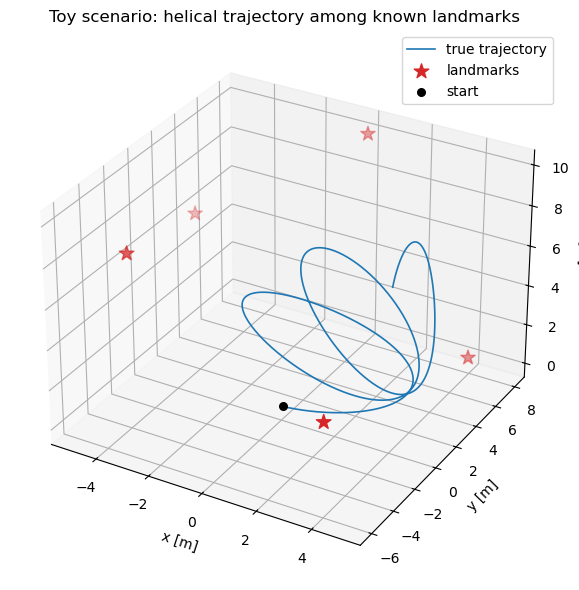

In [5]:
landmarks_dense = np.array([
    [ 5.0,  5.0,  2.0],
    [-5.0,  4.0,  6.0],
    [ 4.0, -6.0,  4.0],
    [-4.0, -4.0,  8.0],
    [ 0.0,  8.0, 10.0],
])

truth, _, _ = simulate(np.random.default_rng(int(0)), landmarks_dense, 40)
P_traj = np.array([Tk.t().copy() for Tk in truth])

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")
ax.plot(*P_traj.T, lw=1.2, label="true trajectory")
ax.scatter(*landmarks_dense.T, marker="*", s=120, color="tab:red", label="landmarks")
ax.scatter(*P_traj[0], color="k", s=30, label="start")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend()
ax.set_title("Toy scenario: helical trajectory among known landmarks")
plt.tight_layout()
plt.show()

## 3. Three filters, one difference

All three filters below are *identical* Kalman filters: predict
$P^- = F P F^\top + G Q G^\top$, update with gain $K = P^-H^\top(HP^-H^\top + R_n)^{-1}$, inject the
correction, repeat. The mean propagation is even the same code
($\hat{\mathbf{T}}^+ = \hat{\mathbf{T}}\,\mathbf{U}$). The *only* thing that differs is the
definition of the error state whose covariance $P$ tracks — and therefore what $F$, $H$, and the
injection look like.

A word on why we don't just run a vanilla EKF on the 7 raw parameters $(\mathbf{p}, \mathbf{q})$:
the quaternion constraint $\lVert\mathbf{q}\rVert = 1$ makes the 7-dimensional covariance singular, and
additive quaternion corrections leave the manifold. Every practical filter therefore tracks a
*minimal* (6-DoF) error parametrization around the estimate — the whole question is which one.

## 4. Filter 1: the error-state KF ($SO(3)\times\mathbb{R}^3$ error)

The standard ESKF treats position and orientation errors *separately*: an additive, world-frame
position error and a local (right) rotation error,

$$\mathbf{p} = \hat{\mathbf{p}} + \delta\mathbf{p}, \qquad
\mathbf{R} = \hat{\mathbf{R}}\,\mathrm{Exp}(\delta\boldsymbol{\theta}), \qquad
\delta\mathbf{x} = \begin{bmatrix}\delta\mathbf{p}\\ \delta\boldsymbol{\theta}\end{bmatrix}.$$

**Propagation.** The nominal state integrates the odometry,
$\hat{\mathbf{p}}^+ = \hat{\mathbf{p}} + \hat{\mathbf{R}}\tilde{\mathbf{v}}\Delta t$,
$\hat{\mathbf{R}}^+ = \hat{\mathbf{R}}\,\mathrm{Exp}(\tilde{\boldsymbol{\omega}}\Delta t)$.
Substituting the error definitions into the true dynamics and keeping first-order terms
(using $\mathbf{R} \approx \hat{\mathbf{R}}(\mathbf{I} + \delta\boldsymbol{\theta}^\wedge)$ and
$\hat{\mathbf{R}}\,\delta\boldsymbol{\theta}^\wedge\tilde{\mathbf{v}} = -\hat{\mathbf{R}}\,\tilde{\mathbf{v}}^\wedge\delta\boldsymbol{\theta}$):

$$\delta\mathbf{p}^+ = \delta\mathbf{p} - \hat{\mathbf{R}}\,\tilde{\mathbf{v}}^\wedge\,\delta\boldsymbol{\theta}\,\Delta t - \hat{\mathbf{R}}\,\mathbf{n}_v\,\Delta t, \qquad
\delta\boldsymbol{\theta}^+ = \mathrm{Exp}(\tilde{\boldsymbol{\omega}}\Delta t)^\top\,\delta\boldsymbol{\theta} - \mathbf{n}_\omega\,\Delta t,$$

$$F_{\text{ESKF}} = \begin{bmatrix}\mathbf{I} & -\hat{\mathbf{R}}\,\tilde{\mathbf{v}}^\wedge\Delta t\\ \mathbf{0} & \mathrm{Exp}(\tilde{\boldsymbol{\omega}}\Delta t)^\top\end{bmatrix}, \qquad
G_{\text{ESKF}} = \begin{bmatrix}-\hat{\mathbf{R}}\Delta t & \mathbf{0}\\ \mathbf{0} & -\mathbf{I}\Delta t\end{bmatrix}.$$

Note $F$ **depends on the estimate** $\hat{\mathbf{R}}$: if the attitude estimate is wrong, the
covariance is propagated with the wrong Jacobian. This is a first-order linearization — there is
no error size at which it becomes exact.

**Update.** Linearizing $\mathbf{y}_i = \mathbf{R}^\top(\boldsymbol{\ell}_i - \mathbf{p}) + \boldsymbol{\nu}$
about the estimate, with $\hat{\mathbf{y}}_i = \hat{\mathbf{R}}^\top(\boldsymbol{\ell}_i - \hat{\mathbf{p}})$:

$$\mathbf{z}_i = \mathbf{y}_i - \hat{\mathbf{y}}_i \approx
-\hat{\mathbf{R}}^\top\delta\mathbf{p} + \hat{\mathbf{y}}_i^\wedge\,\delta\boldsymbol{\theta} + \boldsymbol{\nu}_i
\quad\Longrightarrow\quad
H_i = \begin{bmatrix}-\hat{\mathbf{R}}^\top & \hat{\mathbf{y}}_i^\wedge\end{bmatrix},$$

again estimate-dependent through both $\hat{\mathbf{R}}$ and $\hat{\mathbf{y}}_i$. After computing
$\delta\hat{\mathbf{x}} = K\mathbf{z}$, the correction is *injected* and the error reset:
$\hat{\mathbf{p}} \leftarrow \hat{\mathbf{p}} + \delta\hat{\mathbf{p}}$,
$\hat{\mathbf{R}} \leftarrow \hat{\mathbf{R}}\,\mathrm{Exp}(\delta\hat{\boldsymbol{\theta}})$.
(We omit the reset Jacobian, which is $\mathbf{I} + O(\delta\boldsymbol{\theta})$; see Solà §6.3.)

In [6]:
def joseph(P, K, H, Rn):
    """Joseph-form covariance update (numerically symmetric and PSD-preserving)."""
    IKH = np.eye(P.shape[0]) - K @ H
    P = IKH @ P @ IKH.T + K @ Rn @ K.T
    return 0.5 * (P + P.T)

def kf_update(P, H, z, Rn):
    """Standard KF update; returns (correction, new P)."""
    S = H @ P @ H.T + Rn
    K = P @ H.T @ np.linalg.solve(S, np.eye(S.shape[0]))
    return K @ z, joseph(P, K, H, Rn)


class ESKF:
    """Error-state KF with error [dp (world, additive); dtheta (local)]."""

    def __init__(self, T0, P0):
        self.p = T0.t().copy()
        self.R = SO3(T0.q().array())
        self.P = P0.copy()

    def predict(self, u):
        v, w = u[:3], u[3:]
        Rm = self.R.R()
        F = np.eye(6)
        F[0:3, 3:6] = -Rm @ skew(v) * dt
        F[3:6, 3:6] = SO3.Exp(w * dt).R().T
        G = np.zeros((6, 6))
        G[0:3, 0:3] = -Rm * dt
        G[3:6, 3:6] = -np.eye(3) * dt
        self.p = self.p + Rm @ v * dt
        self.R = self.R * SO3.Exp(w * dt)
        self.P = F @ self.P @ F.T + G @ Qu @ G.T

    def update(self, ys, landmarks):
        Rm = self.R.R()
        H = np.zeros((3 * len(landmarks), 6))
        z = np.zeros(3 * len(landmarks))
        for i, l in enumerate(landmarks):
            yhat = Rm.T @ (l - self.p)
            H[3*i:3*i+3, 0:3] = -Rm.T
            H[3*i:3*i+3, 3:6] = skew(yhat)
            z[3*i:3*i+3] = ys[i] - yhat
        Rn = sigma_y**2 * np.eye(3 * len(landmarks))
        dx, self.P = kf_update(self.P, H, z, Rn)
        self.p = self.p + dx[0:3]              # additive injection
        self.R = self.R * SO3.Exp(dx[3:6])     # multiplicative injection

    def pose(self):
        return SE3(np.concatenate([self.p, self.R.array()]))

    def err(self, Ttrue):
        """Estimation error in this filter's own coordinates."""
        dp = Ttrue.t() - self.p
        dth = SO3.Log(canon_q(self.R.inverse() * Ttrue.q()))
        return np.concatenate([dp, dth])

## 5. Filter 2: the left-invariant EKF (body-frame $SE(3)$ error)

Now define the error through the group operation, using the module's own $\oplus$:

$$\boldsymbol{\xi} = \mathrm{Log}\!\left(\hat{\mathbf{T}}^{-1}\mathbf{T}\right) \in \mathbb{R}^6
\qquad\Longleftrightarrow\qquad \mathbf{T} = \hat{\mathbf{T}}\,\mathrm{Exp}(\boldsymbol{\xi}) = \hat{\mathbf{T}} \oplus \boldsymbol{\xi}.$$

$\eta_L = \hat{\mathbf{T}}^{-1}\mathbf{T}$ is unchanged when both $\mathbf{T}$ and $\hat{\mathbf{T}}$ are
left-translated by any $\mathbf{G} \in SE(3)$ (a world-frame change), hence *left-invariant error*;
$\boldsymbol{\xi}$ lives in the body frame. Unlike the ESKF error, the $\mathbf{V}(\boldsymbol{\theta})$ coupling of the
$SE(3)$ exponential ties the translation and rotation errors together.

**Propagation — the log-linear property.** With $\mathbf{U} = \mathrm{Exp}(\Delta t\,\tilde{\mathbf{u}})$
and the noiseless dynamics $\mathbf{T}^+ = \mathbf{T}\mathbf{U}$, $\hat{\mathbf{T}}^+ = \hat{\mathbf{T}}\mathbf{U}$:

$$\mathrm{Exp}(\boldsymbol{\xi}^+) = \left(\hat{\mathbf{T}}\mathbf{U}\right)^{-1}\mathbf{T}\mathbf{U}
= \mathbf{U}^{-1}\,\mathrm{Exp}(\boldsymbol{\xi})\,\mathbf{U}
= \mathrm{Exp}\!\left(\mathrm{Ad}_{\mathbf{U}^{-1}}\,\boldsymbol{\xi}\right)
\;\;\Longrightarrow\;\;
\boldsymbol{\xi}^+ = \mathrm{Ad}_{\mathbf{U}^{-1}}\,\boldsymbol{\xi}\quad\textbf{exactly}.$$

This is the discrete-time face of Barrau & Bonnabel's *log-linear* property of group-affine
dynamics. Two things just happened that never happen for the ESKF:

1. The error transition $F = \mathrm{Ad}_{\mathbf{U}^{-1}}$ depends **only on the odometry input**, never on the state estimate.
2. The relation is **exact for arbitrarily large errors** — nothing was linearized. (Noise enters to first order: $\boldsymbol{\xi}^+ \approx \mathrm{Ad}_{\mathbf{U}^{-1}}\boldsymbol{\xi} - \Delta t\,\mathbf{n}$, so $G = -\Delta t\,\mathbf{I}_6$ and the process noise covariance $\Delta t^2 Q_u$ is constant.)

**Update.** With $\hat{\mathbf{y}}_i = \hat{\mathbf{T}}^{-1}\cdot\boldsymbol{\ell}_i$ the predicted body-frame
landmark, substitute $\mathbf{T}^{-1} = \mathrm{Exp}(-\boldsymbol{\xi})\,\hat{\mathbf{T}}^{-1}$:

$$\mathbf{y}_i = \mathrm{Exp}(-\boldsymbol{\xi})\cdot\hat{\mathbf{y}}_i + \boldsymbol{\nu}_i
\approx \hat{\mathbf{y}}_i - \boldsymbol{\rho} - \boldsymbol{\theta}^\wedge\hat{\mathbf{y}}_i + \boldsymbol{\nu}_i
\quad\Longrightarrow\quad
\mathbf{z}_i = \mathbf{y}_i - \hat{\mathbf{y}}_i, \qquad H_i = \begin{bmatrix}-\mathbf{I}_3 & \hat{\mathbf{y}}_i^\wedge\end{bmatrix}.$$

$H$ no longer contains $\hat{\mathbf{R}}$ — only the predicted measurement itself. The correction is a
right-plus: $\hat{\mathbf{T}} \leftarrow \hat{\mathbf{T}} \oplus K\mathbf{z}$.

In [7]:
class LIEKF:
    """Left-invariant EKF: error xi = Log(That^-1 T), i.e. T = That + xi."""

    def __init__(self, T0, P0):
        self.T = SE3(T0.array())
        self.P = P0.copy()

    def predict(self, u):
        U = SE3.Exp(dt * u)
        self.T = self.T * U
        F = Ad(U.inverse())                    # input only -- no state estimate
        self.P = F @ self.P @ F.T + dt**2 * Qu

    def update(self, ys, landmarks):
        Tinv = self.T.inverse()
        H = np.zeros((3 * len(landmarks), 6))
        z = np.zeros(3 * len(landmarks))
        for i, l in enumerate(landmarks):
            yhat = Tinv * l
            H[3*i:3*i+3, 0:3] = -np.eye(3)
            H[3*i:3*i+3, 3:6] = skew(yhat)
            z[3*i:3*i+3] = ys[i] - yhat
        Rn = sigma_y**2 * np.eye(3 * len(landmarks))
        dxi, self.P = kf_update(self.P, H, z, Rn)
        self.T = self.T + dxi                  # right-plus injection

    def pose(self):
        return SE3(self.T.array())

    def err(self, Ttrue):
        return SE3.Log(canon(self.T.inverse() * Ttrue))

## 6. Filter 3: the right-invariant EKF (world-frame $SE(3)$ error)

Flip the error to the other side of the estimate:

$$\boldsymbol{\zeta} = \mathrm{Log}\!\left(\mathbf{T}\,\hat{\mathbf{T}}^{-1}\right)
\qquad\Longleftrightarrow\qquad \mathbf{T} = \mathrm{Exp}(\boldsymbol{\zeta})\,\hat{\mathbf{T}}.$$

$\eta_R = \mathbf{T}\hat{\mathbf{T}}^{-1}$ is invariant to *right* translations — and our dynamics
$\mathbf{T}^+ = \mathbf{T}\mathbf{U}$ are exactly a right translation. So the noiseless error doesn't
move at all:

$$\mathrm{Exp}(\boldsymbol{\zeta}^+) = \mathbf{T}\mathbf{U}\,\left(\hat{\mathbf{T}}\mathbf{U}\right)^{-1}
= \mathbf{T}\hat{\mathbf{T}}^{-1} = \mathrm{Exp}(\boldsymbol{\zeta})
\;\;\Longrightarrow\;\; F = \mathbf{I}_6\quad\textbf{exactly}.$$

The process noise, injected in the body frame, must be carried to the world-frame error through the
adjoint: $\boldsymbol{\zeta}^+ \approx \boldsymbol{\zeta} + \mathrm{Ad}_{\hat{\mathbf{T}}^+}\mathbf{w}$, so
$P^+ = P + \mathrm{Ad}_{\hat{\mathbf{T}}^+}\,\Delta t^2 Q_u\,\mathrm{Ad}_{\hat{\mathbf{T}}^+}^\top$. (The lever-arm
growth of translational uncertainty with distance from the origin is real physics, not an artifact —
some state dependence has to live *somewhere*.)

**Update.** Here is the payoff for matching the error to this measurement model. Map the body-frame
measurement into the world frame with the estimate and compare against the known landmark:

$$\mathbf{z}_i \triangleq \hat{\mathbf{T}}\cdot\mathbf{y}_i - \boldsymbol{\ell}_i
= \hat{\mathbf{T}}\mathbf{T}^{-1}\cdot\boldsymbol{\ell}_i - \boldsymbol{\ell}_i + \hat{\mathbf{R}}\boldsymbol{\nu}_i
= \mathrm{Exp}(-\boldsymbol{\zeta})\cdot\boldsymbol{\ell}_i - \boldsymbol{\ell}_i + \hat{\mathbf{R}}\boldsymbol{\nu}_i
\approx -\boldsymbol{\rho} + \boldsymbol{\ell}_i^\wedge\boldsymbol{\theta} + \hat{\mathbf{R}}\boldsymbol{\nu}_i,$$

$$H_i = \begin{bmatrix}-\mathbf{I}_3 & \boldsymbol{\ell}_i^\wedge\end{bmatrix}.$$

$H$ contains **only the known landmark position** — not the estimate, not even the predicted
measurement. However wrong $\hat{\mathbf{T}}$ is, the measurement model is linearized in exactly the
right place; the estimate cannot poison the gain. (The measurement noise picks up a rotation,
$\hat{\mathbf{R}}\boldsymbol{\nu}$, but with isotropic $\sigma_y^2\mathbf{I}$ that's covariance-invariant — we keep the
general form in code.) The correction is now a *left* multiplication:
$\hat{\mathbf{T}} \leftarrow \mathrm{Exp}(K\mathbf{z})\,\hat{\mathbf{T}}$.

> **Naming caveat:** which error is called "left"- vs. "right"-invariant, and which observation form
> pairs with which, varies across the literature (compare Barrau & Bonnabel 2017/2018 with Hartley
> et al. 2020). The algebra above is self-contained: for *this* system — right-translation dynamics
> and $\mathbf{y} = \mathbf{T}^{-1}\cdot\boldsymbol{\ell}$ measurements — the world-frame error
> $\boldsymbol{\zeta}$ gets exact, state-independent $F$ *and* $H$.

In [8]:
class RIEKF:
    """Right-invariant EKF: error zeta = Log(T That^-1), i.e. T = Exp(zeta) That."""

    def __init__(self, T0, P0):
        self.T = SE3(T0.array())
        self.P = P0.copy()

    def predict(self, u):
        U = SE3.Exp(dt * u)
        self.T = self.T * U
        AdT = Ad(self.T)                       # F = I exactly; noise enters via Ad
        self.P = self.P + AdT @ (dt**2 * Qu) @ AdT.T

    def update(self, ys, landmarks):
        H = np.zeros((3 * len(landmarks), 6))
        z = np.zeros(3 * len(landmarks))
        for i, l in enumerate(landmarks):
            H[3*i:3*i+3, 0:3] = -np.eye(3)
            H[3*i:3*i+3, 3:6] = skew(l)        # known landmark only!
            z[3*i:3*i+3] = (self.T * ys[i]) - l
        Rm = self.T.q().R()
        Rn = np.kron(np.eye(len(landmarks)), Rm @ (sigma_y**2 * np.eye(3)) @ Rm.T)
        dz, self.P = kf_update(self.P, H, z, Rn)
        self.T = SE3.Exp(dz) * self.T          # left injection
    def pose(self):
        return SE3(self.T.array())

    def err(self, Ttrue):
        return SE3.Log(canon(Ttrue * self.T.inverse()))

### Scorecard so far

| | error | $F$ | $H_i$ | noise mapping |
|---|---|---|---|---|
| **ESKF** | $(\delta\mathbf{p}, \delta\boldsymbol{\theta})$ | $F(\hat{\mathbf{R}}, \tilde{\mathbf{u}})$ — first-order | $\left[-\hat{\mathbf{R}}^\top \;\; \hat{\mathbf{y}}_i^\wedge\right]$ | constant |
| **Left-IEKF** | $\boldsymbol{\xi} = \mathrm{Log}(\hat{\mathbf{T}}^{-1}\mathbf{T})$ | $\mathrm{Ad}_{\mathbf{U}^{-1}}$ — input-only, **exact** | $\left[-\mathbf{I} \;\; \hat{\mathbf{y}}_i^\wedge\right]$ | constant |
| **Right-IEKF** | $\boldsymbol{\zeta} = \mathrm{Log}(\mathbf{T}\hat{\mathbf{T}}^{-1})$ | $\mathbf{I}$ — **exact** | $\left[-\mathbf{I} \;\; \boldsymbol{\ell}_i^\wedge\right]$ — state-free | $\mathrm{Ad}_{\hat{\mathbf{T}}}$, $\hat{\mathbf{R}}$ |

Reading the table, the hypothesis for the experiments is clear: when errors are small every filter
linearizes at essentially the truth and they should be indistinguishable; when errors are *large*,
the filters whose Jacobians don't depend on the (wrong) estimate should degrade more gracefully,
with the right-IEKF — whose $F$ and $H$ are both immune — the most robust of all.

## 7. Test harness

One function runs all three filters on identical data. Consistency is scored with the
**normalized estimation error squared** (NEES),
$\epsilon_k = \mathbf{e}_k^\top P_k^{-1}\mathbf{e}_k$, where each filter's error $\mathbf{e}_k$ is
evaluated *in its own error coordinates* (that is the covariance it claims to track). For a
consistent filter $\epsilon_k \sim \chi^2_6$: mean 6, and 95% of samples inside
$[1.24,\ 14.45]$.

In [9]:
from dataclasses import dataclass, field

FILTERS = {"ESKF": ESKF, "Left-IEKF": LIEKF, "Right-IEKF": RIEKF}
COLORS = {"ESKF": "tab:blue", "Left-IEKF": "tab:orange", "Right-IEKF": "tab:green"}

@dataclass
class RunLog:
    nees: list = field(default_factory=list)
    rot_err: list = field(default_factory=list)   # geodesic rotation error [rad]
    pos_err: list = field(default_factory=list)   # euclidean position error [m]
    sig: list = field(default_factory=list)       # 3-sigma bounds (own coordinates)
    err: list = field(default_factory=list)       # error vector (own coordinates)

def run_filters(truth, odom, meas, T0, P0, landmarks):
    filters = {name: cls(T0, P0) for name, cls in FILTERS.items()}
    logs = {name: RunLog() for name in FILTERS}
    for k in range(N):
        for f in filters.values():
            f.predict(odom[k])
        if meas[k] is not None:
            for f in filters.values():
                f.update(meas[k], landmarks)
        Tt = truth[k]
        for name, f in filters.items():
            e = f.err(Tt)
            log = logs[name]
            log.err.append(e)
            log.nees.append(e @ np.linalg.solve(f.P, e))
            log.sig.append(3 * np.sqrt(np.diag(f.P)))
            That = f.pose()   # bind first: .t() is a view that must not outlive the object
            log.rot_err.append(np.linalg.norm(SO3.Log(canon_q(That.q().inverse() * Tt.q()))))
            log.pos_err.append(np.linalg.norm(Tt.t() - That.t()))
    return logs

CHI2_6_LO, CHI2_6_HI = 1.237, 14.449   # 95% interval of chi^2 with 6 DoF
tgrid = np.arange(N) * dt

## 8. Experiment 1: nominal conditions

Small initial error (sampled from the filters' initial covariance), five landmarks, measurements
every 2 s. This is the regime every deployed filter hopes to live in.

In [10]:
rng = np.random.default_rng(int(42))
meas_every = 40                                   # 2 s between landmark updates

truth, odom, meas = simulate(rng, landmarks_dense, meas_every)

P0 = np.diag([0.1**2]*3 + [0.05**2]*3)
xi0 = np.concatenate([0.1 * rng.standard_normal(3), 0.05 * rng.standard_normal(3)])
T0 = SE3.identity() + xi0                         # perturbed initial estimate

logs_nom = run_filters(truth, odom, meas, T0, P0, landmarks_dense)

for name, log in logs_nom.items():
    print(f"{name:>10}:  mean rot err {np.degrees(np.mean(log.rot_err[N//2:])):.2f} deg | "
          f"mean pos err {np.mean(log.pos_err[N//2:]):.3f} m | "
          f"mean NEES {np.mean(log.nees):.1f}  (consistent ~ 6)")

      ESKF:  mean rot err 0.55 deg | mean pos err 0.058 m | mean NEES 6.2  (consistent ~ 6)
 Left-IEKF:  mean rot err 0.55 deg | mean pos err 0.053 m | mean NEES 5.9  (consistent ~ 6)
Right-IEKF:  mean rot err 0.55 deg | mean pos err 0.053 m | mean NEES 5.9  (consistent ~ 6)


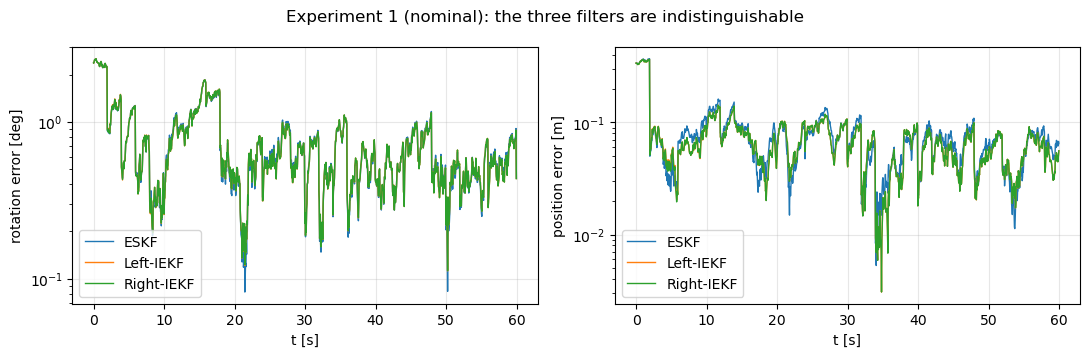

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for name, log in logs_nom.items():
    axes[0].semilogy(tgrid, np.degrees(log.rot_err), color=COLORS[name], lw=1, label=name)
    axes[1].semilogy(tgrid, log.pos_err, color=COLORS[name], lw=1, label=name)
axes[0].set_ylabel("rotation error [deg]"); axes[1].set_ylabel("position error [m]")
for ax in axes:
    ax.set_xlabel("t [s]"); ax.grid(alpha=0.3); ax.legend()
fig.suptitle("Experiment 1 (nominal): the three filters are indistinguishable")
plt.tight_layout()
plt.show()

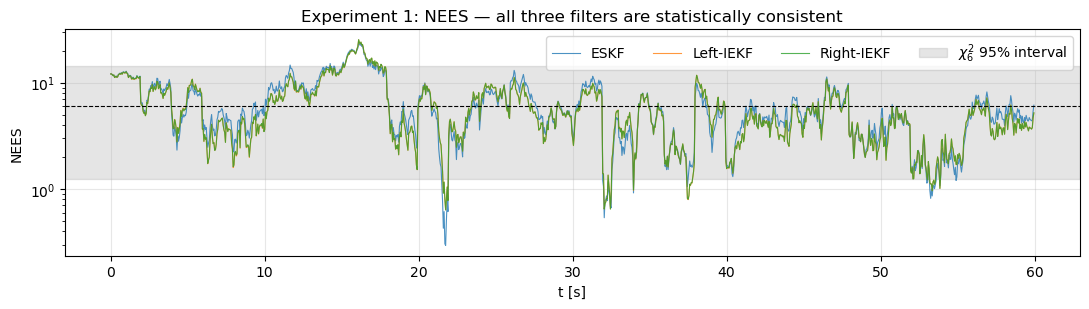

In [12]:
fig, ax = plt.subplots(figsize=(11, 3.2))
for name, log in logs_nom.items():
    ax.semilogy(tgrid, log.nees, color=COLORS[name], lw=0.8, alpha=0.8, label=name)
ax.axhspan(CHI2_6_LO, CHI2_6_HI, color="gray", alpha=0.2, label=r"$\chi^2_6$ 95% interval")
ax.axhline(6, color="k", lw=0.8, ls="--")
ax.set_xlabel("t [s]"); ax.set_ylabel("NEES")
ax.grid(alpha=0.3); ax.legend(ncol=4)
ax.set_title("Experiment 1: NEES — all three filters are statistically consistent")
plt.tight_layout()
plt.show()

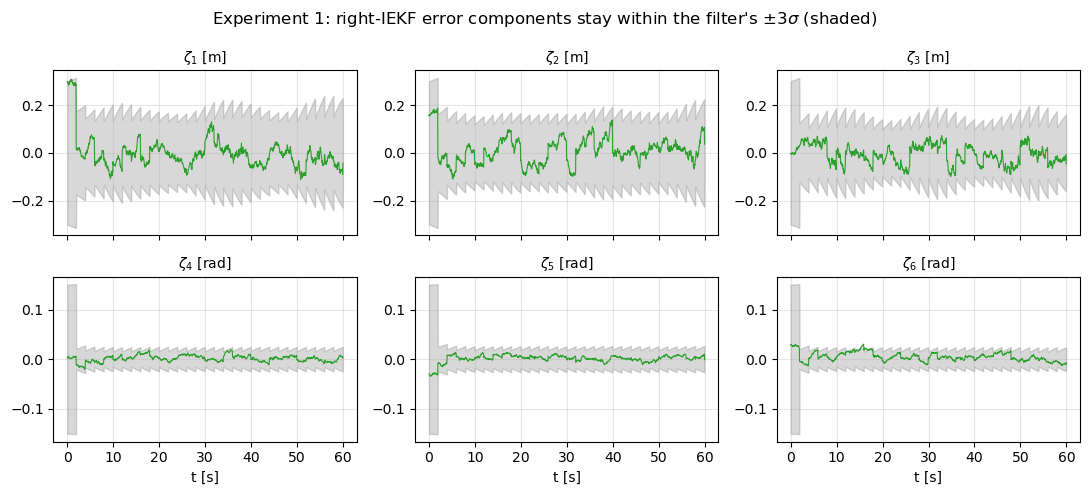

In [13]:
# Covariance sanity: per-axis error inside its own +/-3 sigma envelope (right-IEKF shown;
# the other two look the same in this regime).
log = logs_nom["Right-IEKF"]
err = np.array(log.err); sig = np.array(log.sig)
labels = [r"$\zeta_1$ [m]", r"$\zeta_2$ [m]", r"$\zeta_3$ [m]",
          r"$\zeta_4$ [rad]", r"$\zeta_5$ [rad]", r"$\zeta_6$ [rad]"]
fig, axes = plt.subplots(2, 3, figsize=(11, 5), sharex=True)
for j, ax in enumerate(axes.flat):
    ax.plot(tgrid, err[:, j], lw=0.8, color=COLORS["Right-IEKF"])
    ax.fill_between(tgrid, -sig[:, j], sig[:, j], color="gray", alpha=0.3)
    ax.set_title(labels[j], fontsize=10)
    ax.grid(alpha=0.3)
for ax in axes[1]:
    ax.set_xlabel("t [s]")
fig.suptitle(r"Experiment 1: right-IEKF error components stay within the filter's $\pm3\sigma$ (shaded)")
plt.tight_layout()
plt.show()

**Takeaway 1.** In the small-error regime the three filters agree to within noise — same
accuracy, same (healthy) consistency. All the linearization points are near the truth, so *where*
you linearize barely matters. If your system never sees large errors, the error parametrization is
a matter of taste and software convenience.

## 9. Experiment 2: large initialization error, lean measurements

Now the gloves come off: initial errors of $\sigma_{p,0} = 5$ m and $\sigma_{\theta,0} = 1.5$ rad
*per axis* (samples routinely exceed 150° of attitude error), only three landmarks, and 5 s of
dead-reckoning between landmark updates. We Monte-Carlo this over independent trajectories, noise,
and initial errors, and compare median error trajectories, consistency, and divergence rates.

In [14]:
landmarks_lean = landmarks_dense[:3]
meas_every_lean = 100                              # 5 s between updates
sig_p0, sig_th0 = 5.0, 1.5
P0_big = np.diag([sig_p0**2]*3 + [sig_th0**2]*3)

M_RUNS = 25
mc = {name: {"nees": [], "rot": [], "pos": []} for name in FILTERS}
init_rots = []
for m in range(M_RUNS):
    r = np.random.default_rng(int(7000 + m))
    truth, odom, meas = simulate(r, landmarks_lean, meas_every_lean)
    xi0 = np.concatenate([sig_p0 * r.standard_normal(3), sig_th0 * r.standard_normal(3)])
    T0 = SE3.identity() + xi0
    init_rots.append(np.degrees(np.linalg.norm(SO3.Log(canon_q(T0.q())))))
    logs = run_filters(truth, odom, meas, T0, P0_big, landmarks_lean)
    for name, log in logs.items():
        mc[name]["nees"].append(log.nees)
        mc[name]["rot"].append(log.rot_err)
        mc[name]["pos"].append(log.pos_err)
for name in FILTERS:
    for key in mc[name]:
        mc[name][key] = np.array(mc[name][key])

print(f"{M_RUNS} Monte Carlo runs complete")
print(f"initial attitude errors: median {np.median(init_rots):.0f} deg, max {np.max(init_rots):.0f} deg")

25 Monte Carlo runs complete
initial attitude errors: median 133 deg, max 177 deg


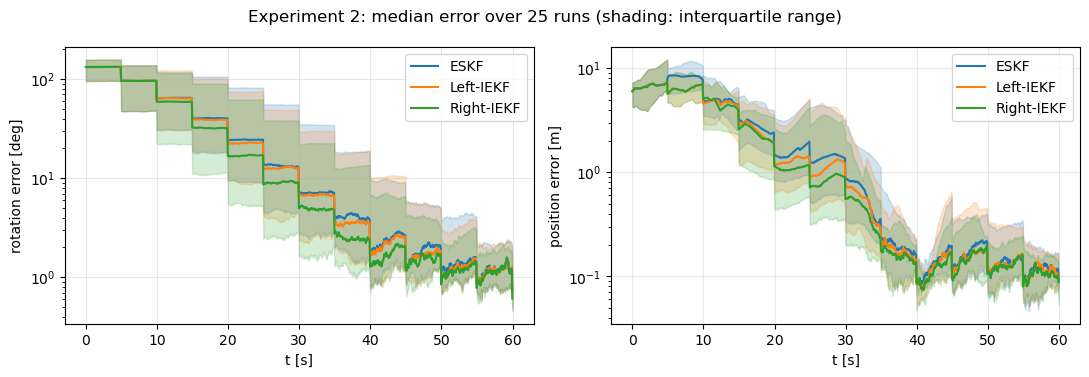

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
for name in FILTERS:
    rot = np.degrees(mc[name]["rot"]); pos = mc[name]["pos"]
    for ax, dat in zip(axes, (rot, pos)):
        med = np.median(dat, axis=0)
        q1, q3 = np.percentile(dat, [25, 75], axis=0)
        ax.semilogy(tgrid, med, color=COLORS[name], lw=1.5, label=name)
        ax.fill_between(tgrid, q1, q3, color=COLORS[name], alpha=0.2)
axes[0].set_ylabel("rotation error [deg]"); axes[1].set_ylabel("position error [m]")
for ax in axes:
    ax.set_xlabel("t [s]"); ax.grid(alpha=0.3); ax.legend()
fig.suptitle(f"Experiment 2: median error over {M_RUNS} runs (shading: interquartile range)")
plt.tight_layout()
plt.show()

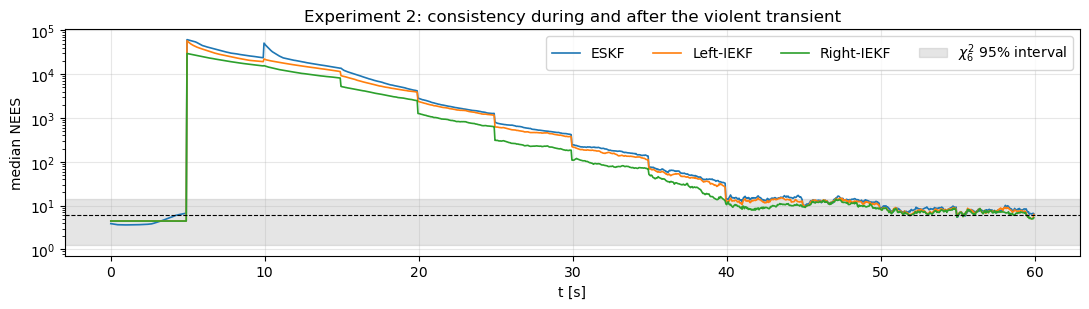

In [16]:
fig, ax = plt.subplots(figsize=(11, 3.2))
for name in FILTERS:
    ax.semilogy(tgrid, np.median(mc[name]["nees"], axis=0), color=COLORS[name], lw=1.2, label=name)
ax.axhspan(CHI2_6_LO, CHI2_6_HI, color="gray", alpha=0.2, label=r"$\chi^2_6$ 95% interval")
ax.axhline(6, color="k", lw=0.8, ls="--")
ax.set_xlabel("t [s]"); ax.set_ylabel("median NEES")
ax.grid(alpha=0.3); ax.legend(ncol=4)
ax.set_title("Experiment 2: consistency during and after the violent transient")
plt.tight_layout()
plt.show()

In [17]:
print(f"{'filter':>12} | {'rot err @ t=20s, median / 90th pct':>34} | {'NEES (2nd half)':>16}")
print("-" * 70)
for name in FILTERS:
    r20 = np.degrees(mc[name]["rot"][:, int(20/dt)])
    nees2 = np.median(mc[name]["nees"][:, N//2:])
    print(f"{name:>12} | {np.median(r20):14.1f} / {np.percentile(r20, 90):10.1f} deg | {nees2:16.1f}")

      filter | rot err @ t=20s, median / 90th pct |  NEES (2nd half)
----------------------------------------------------------------------
        ESKF |           24.3 /      128.4 deg |             17.6
   Left-IEKF |           22.4 /      126.6 deg |             15.6
  Right-IEKF |           16.7 /      118.6 deg |             11.9


**Takeaway 2.** Under large errors the ordering predicted by the Jacobian table appears in the
data. The right-IEKF converges fastest and with the lightest error tails: its gain is computed from
Jacobians that are *correct by construction* regardless of how wrong the estimate is, so every
update pulls in a useful direction. The left-IEKF sits in between — its propagation is exact but its
$H$ still linearizes about the (wrong) predicted measurement. The ESKF is the slowest to converge
and carries the heaviest tails: with a badly wrong $\hat{\mathbf{R}}$, both its $F$ and its $H$ are
evaluated far from the truth, and the resulting gains can push the estimate in unhelpful directions
(push the initial errors or the measurement sparsity further and this mechanism tips into outright
divergence — for the ESKF first). The NEES plot tells the same story from the consistency angle —
all three are overconfident during the transient (no EKF variant escapes a violently nonlinear
update with a linear covariance update), but the invariant filters recover to the $\chi^2_6$ band
sooner.

## 10. Closing notes

**What made the IEKF work here.** Two structural facts about the toy problem, both worth checking
for in your own systems before reaching for an IEKF:

1. The dynamics are *group-affine* (here, simply right multiplication by an input-dependent element), which produces the log-linear property: group-error dynamics that are exactly linear in $\mathrm{Log}$ coordinates, with a state-independent transition matrix.
2. The measurement is a *group action on a known point* ($\mathbf{y} = \mathbf{T}^{-1}\cdot\boldsymbol{\ell}$). Choosing the error on the side of the estimate that cancels $\mathbf{T}$ in the innovation ($\hat{\mathbf{T}}\mathbf{T}^{-1} = \mathrm{Exp}(-\boldsymbol{\zeta})$) makes $H$ exactly state-independent. GPS-style world-frame measurements ($\mathbf{y} = \mathbf{T}\cdot\mathbf{b}$) have the mirror-image structure and pair with the body-frame error $\boldsymbol{\xi}$ instead — same derivation, other side.

So the IEKF can be preferable when:

- Inertial navigation is central to the problem,
- Attitude uncertainty is initially large,
- There are long periods of inertial dead reckoning,
- Motion is highly dynamic,
- The system experiences significant rotations,
- Consistency is especially important (e.g., long-term navigation),

for these are precisely the situations where trajectory-dependent linearization (via suboptimal choice of coordinates) hurts a "conventional filter" the most!


**What this doesn't say.** The ESKF is not broken — in the nominal regime it matched the invariant
filters exactly, and it accommodates states with no group structure (biases, scale factors, clock
errors) without ceremony. IMU-driven systems need the group $SE_2(3)$ (adding velocity) for the
log-linear property to survive, and adding sensor biases (e.g., IMU biases, camera intrinsics, GNSS clock biases) to the state formally breaks invariance ("imperfect IEKF") —
in practice the IEKF's advantages substantially survive both, which is why it has become standard
in legged-robot and aerial-vehicle estimation (Hartley et al. 2020).

**Implementation gotchas we hit** (kept in the notebook on purpose):
- *Quaternion double cover:* canonicalize $q_w \geq 0$ before any $\mathrm{Log}$ used as a metric, or a converged filter looks like a $2\pi$ failure (§1).
- *Consistency scoring:* NEES must be computed in each filter's own error coordinates — comparing $\mathrm{Log}$-errors against an ESKF covariance (or vice versa) silently mixes parametrizations.
- *Bindings lifetime:* `SE3.t()` returns a numpy *view* into the C++ object with no keep-alive (`.array()`, `.q()`, and `.R()` return copies and are safe). Calling `.t()` on a temporary — `f.pose().t()`, `SE3.Exp(tau).t()` — reads freed memory. Bind the object to a variable first (§1, §7).